# LiTS Dataset — Comprehensive Exploratory Data Analysis
**Goal:** Understand every aspect of the LiTS liver+tumor dataset before modeling decisions.

---
## 1. Setup & Imports

In [1]:
import os, json, math, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from PIL import Image

warnings.filterwarnings('ignore')
print('All imports OK')

All imports OK


In [2]:
# === CONFIGURATION ===
IMAGES_DIR = Path(r'D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver Img Dataset')
MASKS_DIR  = Path(r'D:\DATA SCIENCE AND ANALYTICS\Dataset\LiTS_masks')
SPLITS_DIR = Path.cwd().parent / 'data' / 'splits'

OUT_DIR = Path.cwd()
EDA_FILE = OUT_DIR / 'eda_data.txt'
PLOTS_DIR = OUT_DIR / 'eda_plots'
PLOTS_DIR.mkdir(exist_ok=True)

def log(msg, also_print=True):
    with open(EDA_FILE, 'a', encoding='utf-8') as f:
        f.write(str(msg) + '\n')
    if also_print:
        print(msg)

def load_mask(path):
    m = np.array(Image.open(path))
    if m.ndim == 3:
        m = m[:, :, 0]
    return m

def match_mask_size(mask, target_img):
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    if mask.shape != target_img.shape:
        h, w = target_img.shape
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
    return mask

open(EDA_FILE, 'w').close()
log('=' * 70)
log('LITS DATASET — EXPLORATORY DATA ANALYSIS')
log('=' * 70 + '\n')
print(f'Images: {IMAGES_DIR}')
print(f'Masks:  {MASKS_DIR}')
print(f'EDA ->  {EDA_FILE}')
print(f'Plots-> {PLOTS_DIR}/')

LITS DATASET — EXPLORATORY DATA ANALYSIS

Images: D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver Img Dataset
Masks:  D:\DATA SCIENCE AND ANALYTICS\Dataset\LiTS_masks
EDA ->  D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\eda_data.txt
Plots-> D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\eda_plots/


---
## 2. Data Overview

In [3]:
all_images = sorted(IMAGES_DIR.glob('*.png'))
all_masks  = sorted(MASKS_DIR.glob('*.png'))

log('\n## DATA OVERVIEW')
log(f'Images dir:     {IMAGES_DIR}')
log(f'Masks dir:      {MASKS_DIR}')
log(f'Total images:   {len(all_images):,}')
log(f'Total masks:    {len(all_masks):,}')
log(f'Match:          {len(all_images) == len(all_masks)}')

if not all_images:
    raise FileNotFoundError(f'No PNGs found in {IMAGES_DIR}')

sample_img = np.array(Image.open(all_images[0]))
sample_mask = np.array(Image.open(all_masks[0]))
sample_mask = match_mask_size(sample_mask, sample_img)
log(f'\nSample image shape: {sample_img.shape} dtype={sample_img.dtype}'
    f'  min={sample_img.min()} max={sample_img.max()}')
log(f'Sample mask shape:  {sample_mask.shape} dtype={sample_mask.dtype}'
    f'  unique values: {np.unique(sample_mask)}')


## DATA OVERVIEW
Images dir:     D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver Img Dataset
Masks dir:      D:\DATA SCIENCE AND ANALYTICS\Dataset\LiTS_masks
Total images:   58,638
Total masks:    58,638
Match:          True

Sample image shape: (512, 512) dtype=uint8  min=0 max=255
Sample mask shape:  (512, 512) dtype=uint8  unique values: [0]


In [4]:
def extract_volume_id(filename):
    import re
    m = re.search(r'Volume-(\d+)-', filename)
    return int(m.group(1)) if m else None

vol_to_slices = defaultdict(list)
for img_path in all_images:
    vid = extract_volume_id(img_path.name)
    if vid is not None:
        vol_to_slices[vid].append(img_path)

volume_ids = sorted(vol_to_slices.keys())
n_volumes = len(volume_ids)
log(f'\nNumber of volumes: {n_volumes}')
log(f'Volume ID range: {min(volume_ids)} – {max(volume_ids)}')

slices_per_vol = {k: len(v) for k, v in vol_to_slices.items()}
spv = np.array(list(slices_per_vol.values()))
log(f'\nSlices per volume:')
log(f'  Mean:   {spv.mean():.1f}')
log(f'  Std:    {spv.std():.1f}')
log(f'  Min:    {int(spv.min())}')
log(f'  Max:    {int(spv.max())}')
log(f'  Median: {int(np.median(spv))}')


Number of volumes: 131
Volume ID range: 0 – 130

Slices per volume:
  Mean:   447.6
  Std:    274.2
  Min:    74
  Max:    987
  Median: 432


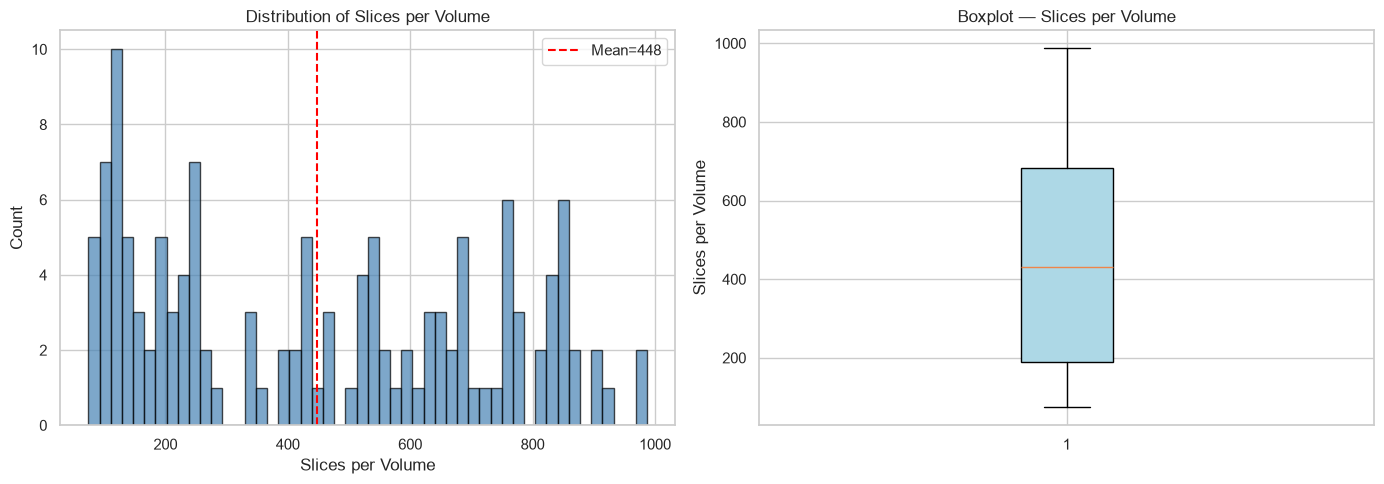

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(spv, bins=min(50, len(set(spv))), edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(spv.mean(), color='red', ls='--', label=f'Mean={spv.mean():.0f}')
axes[0].set_xlabel('Slices per Volume'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Slices per Volume'); axes[0].legend()

axes[1].boxplot(spv, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_ylabel('Slices per Volume')
axes[1].set_title('Boxplot — Slices per Volume')
axes[1].grid(True, axis='y')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'slices_per_volume.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Class Distribution & Imbalance

In [6]:
log('\n## CLASS DISTRIBUTION')

N_SAMPLE = min(5000, len(all_masks))
rng = np.random.RandomState(42)
idx_sample = rng.choice(len(all_masks), N_SAMPLE, replace=False)

tumor_slices_found = 0
fg_pixels_total = 0
bg_pixels_total = 0
for i in idx_sample:
    mask = np.array(Image.open(all_masks[i]))
    img = np.array(Image.open(all_images[i]))
    mask = match_mask_size(mask, img)
    fg = (mask > 0).sum()
    if fg > 0:
        tumor_slices_found += 1
    fg_pixels_total += fg
    bg_pixels_total += (mask == 0).sum()

tumor_slice_pct = 100.0 * tumor_slices_found / N_SAMPLE
pixel_imbalance = bg_pixels_total / max(fg_pixels_total, 1)
log(f'\nSampled {N_SAMPLE:,} slices (estimation):')
log(f'  Tumor-positive slices: {tumor_slices_found} / {N_SAMPLE} ({tumor_slice_pct:.2f}%)')
log(f'  BG pixels: {bg_pixels_total:,}')
log(f'  FG pixels: {fg_pixels_total:,}')
log(f'  Pixel imbalance BG:FG = {pixel_imbalance:.0f} : 1')


## CLASS DISTRIBUTION



Sampled 5,000 slices (estimation):
  Tumor-positive slices: 629 / 5000 (12.58%)
  BG pixels: 1,309,128,188
  FG pixels: 1,591,812
  Pixel imbalance BG:FG = 822 : 1


In [7]:
log('\n## Per-Volume Tumor Burden')

vol_tumor_pct = {}
for vid in sorted(vol_to_slices.keys()):
    vol_masks = [p for p in all_masks if f'mask-{vid:03d}-' in p.name]
    total_px = 0; tumor_px = 0
    for mp in vol_masks:
        m = load_mask(mp)
        total_px += m.size
        tumor_px += (m > 0).sum()
    vol_tumor_pct[vid] = 100.0 * tumor_px / max(total_px, 1) if total_px > 0 else 0

vtp = np.array(list(vol_tumor_pct.values()))
n_zero_tumor = int((vtp == 0).sum())
log(f'  Volumes with zero tumor pixels: {n_zero_tumor} / {len(vtp)} ({100*n_zero_tumor/len(vtp):.1f}%)')
log(f'  Mean tumor % per volume:  {vtp.mean():.4f}%')
log(f'  Median:                  {np.median(vtp):.4f}%')
log(f'  Max:                     {vtp.max():.4f}%')
log(f'  Std:                     {vtp.std():.4f}%')


## Per-Volume Tumor Burden


  Volumes with zero tumor pixels: 13 / 131 (9.9%)
  Mean tumor % per volume:  0.1211%
  Median:                  0.0165%
  Max:                     2.1192%
  Std:                     0.2671%


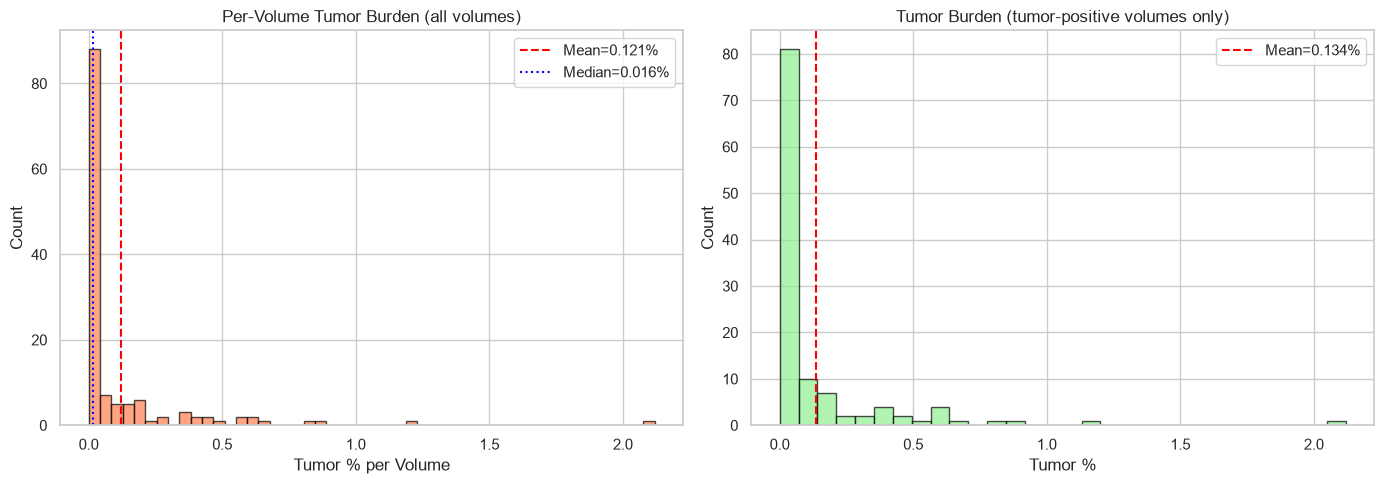

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
non_zero = vtp[vtp > 0]
axes[0].hist(vtp, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(vtp.mean(), color='red', ls='--', label=f'Mean={vtp.mean():.3f}%')
axes[0].axvline(np.median(vtp), color='blue', ls=':', label=f'Median={np.median(vtp):.3f}%')
axes[0].set_xlabel('Tumor % per Volume'); axes[0].set_ylabel('Count')
axes[0].set_title('Per-Volume Tumor Burden (all volumes)'); axes[0].legend()

if len(non_zero) > 5:
    axes[1].hist(non_zero, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[1].axvline(non_zero.mean(), color='red', ls='--', label=f'Mean={non_zero.mean():.3f}%')
    axes[1].set_xlabel('Tumor %'); axes[1].set_ylabel('Count')
    axes[1].set_title('Tumor Burden (tumor-positive volumes only)')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Not enough tumor-positive volumes', ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tumor_burden_per_volume.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Intensity Distribution

In [9]:
log('\n## INTENSITY ANALYSIS')

N_INTENSITY = min(1000, len(all_images))
idxs = rng.choice(len(all_images), N_INTENSITY, replace=False)
all_pixels = []; tumor_pixels = []; bg_pixels = []
for idx in idxs:
    img = np.array(Image.open(all_images[idx]))
    mask = np.array(Image.open(all_masks[idx]))
    mask = match_mask_size(mask, img)
    img = img.ravel()
    mask = mask.ravel()
    all_pixels.extend(img.tolist())
    bg_pixels.extend(img[mask == 0].tolist())
    if (mask > 0).sum() > 0:
        tumor_pixels.extend(img[mask > 0].tolist())

all_pixels = np.array(all_pixels)
bg_pixels = np.array(bg_pixels)
tumor_pixels = np.array(tumor_pixels) if tumor_pixels else np.array([0])

log(f'  Sampled {N_INTENSITY:,} slices')
log(f'  All pixels — mean={all_pixels.mean():.1f} std={all_pixels.std():.1f}'
    f'  range=[{all_pixels.min()}, {all_pixels.max()}]')
log(f'  BG pixels  — mean={bg_pixels.mean():.1f} std={bg_pixels.std():.1f}'
    f'  range=[{bg_pixels.min()}, {bg_pixels.max()}]')
if len(tumor_pixels) > 10:
    log(f'  Tumor px   — mean={tumor_pixels.mean():.1f} std={tumor_pixels.std():.1f}'
        f'  range=[{tumor_pixels.min()}, {tumor_pixels.max()}]')


## INTENSITY ANALYSIS


  Sampled 1,000 slices


  All pixels — mean=44.5 std=84.1  range=[0, 255]


  BG pixels  — mean=44.4 std=84.1  range=[0, 255]
  Tumor px   — mean=109.1 std=102.1  range=[0, 255]


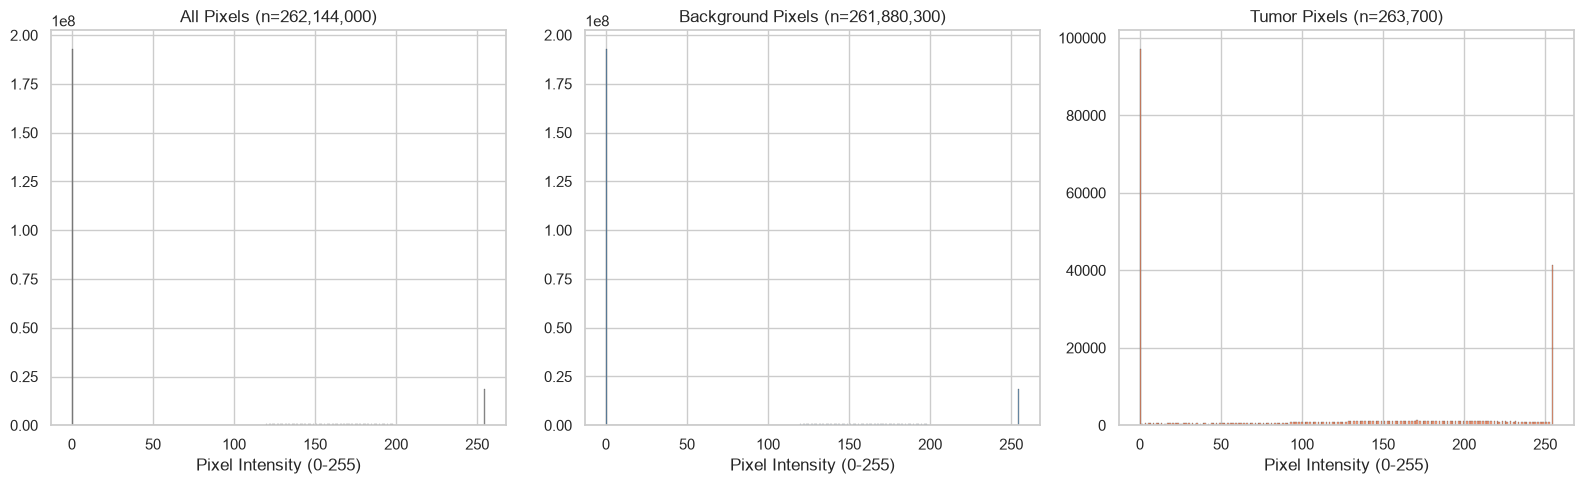

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title, color in zip(
    axes,
    [all_pixels, bg_pixels, tumor_pixels],
    [f'All Pixels (n={len(all_pixels):,})',
     f'Background Pixels (n={len(bg_pixels):,})',
     f'Tumor Pixels (n={len(tumor_pixels):,})'],
    ['gray', 'steelblue', 'coral']):
    if len(data) > 1:
        ax.hist(data, bins=256, color=color, alpha=0.7, edgecolor='black', linewidth=0.2)
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', fontsize=14)
    ax.set_title(title); ax.set_xlabel('Pixel Intensity (0-255)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'intensity_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Tumor Spatial & Morphological Analysis

In [11]:
log('\n## TUMOR MORPHOLOGY')

tumor_sizes = []; tumor_bboxes = []
for mp in all_masks:
    m = load_mask(mp)
    if m.max() == 0:
        continue
    coords = np.argwhere(m > 0)
    tumor_sizes.append(len(coords))
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    tumor_bboxes.append((x_min, y_min, x_max, y_max, m.shape[1], m.shape[0]))

tumor_sizes = np.array(tumor_sizes)
log(f'  Tumor-positive mask slices: {len(tumor_sizes):,}')
log(f'  Tumor pixel count per slice:')
log(f'    Mean:   {tumor_sizes.mean():.1f} px')
log(f'    Median: {np.median(tumor_sizes):.0f} px')
log(f'    Std:    {tumor_sizes.std():.1f} px')
log(f'    Min:    {tumor_sizes.min()} px')
log(f'    Max:    {tumor_sizes.max():,} px')


## TUMOR MORPHOLOGY


  Tumor-positive mask slices: 7,114
  Tumor pixel count per slice:
    Mean:   631.0 px
    Median: 234 px
    Std:    816.7 px
    Min:    1 px
    Max:    3,764 px


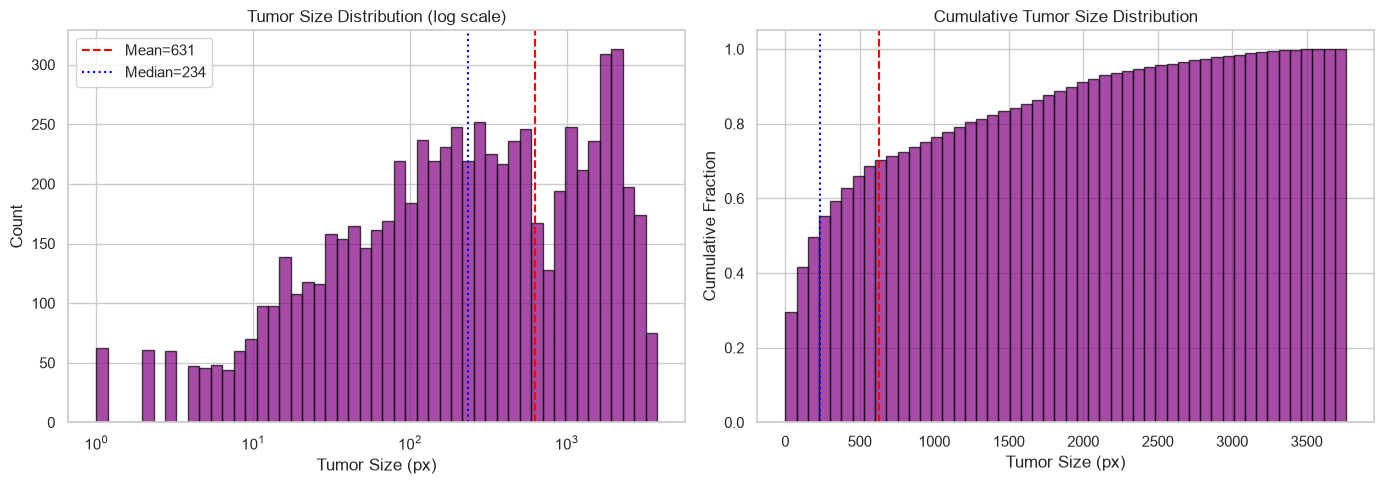

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
log_bins = np.logspace(np.log10(max(tumor_sizes.min(), 1)), np.log10(tumor_sizes.max()), 50)
axes[0].hist(tumor_sizes, bins=log_bins, edgecolor='black', alpha=0.7, color='purple')
axes[0].set_xscale('log')
axes[0].axvline(tumor_sizes.mean(), color='red', ls='--', label=f'Mean={tumor_sizes.mean():.0f}')
axes[0].axvline(np.median(tumor_sizes), color='blue', ls=':', label=f'Median={np.median(tumor_sizes):.0f}')
axes[0].set_xlabel('Tumor Size (px)'); axes[0].set_ylabel('Count')
axes[0].set_title('Tumor Size Distribution (log scale)'); axes[0].legend()

axes[1].hist(tumor_sizes, bins=50, edgecolor='black', alpha=0.7, color='purple',
             cumulative=True, density=True)
axes[1].set_xlabel('Tumor Size (px)'); axes[1].set_ylabel('Cumulative Fraction')
axes[1].set_title('Cumulative Tumor Size Distribution')
axes[1].axvline(tumor_sizes.mean(), color='red', ls='--')
axes[1].axvline(np.median(tumor_sizes), color='blue', ls=':')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tumor_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Tumor Location Heatmap


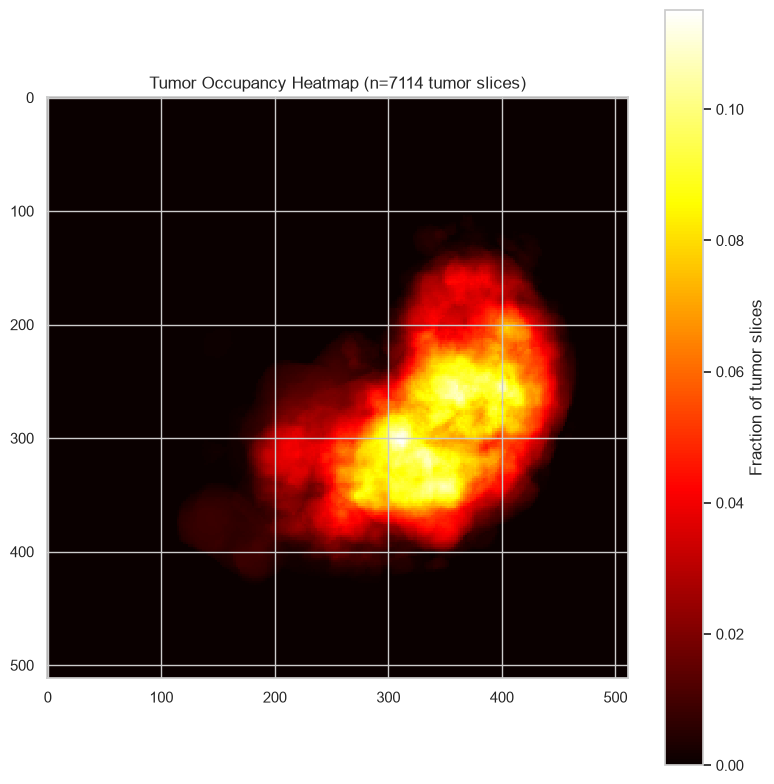

  Peak occupancy: 0.1151


In [13]:
log('\n## Tumor Location Heatmap')
heatmap = np.zeros((512, 512), dtype=np.float64)
tumor_slice_count = 0
for mp in all_masks:
    m = np.array(Image.open(mp))
    if m.max() > 0:
        m = match_mask_size(m, np.zeros((512, 512), dtype=np.uint8))
        heatmap[m > 0] += 1.0
        tumor_slice_count += 1
heatmap /= max(tumor_slice_count, 1)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(heatmap, cmap='hot', interpolation='nearest')
ax.set_title(f'Tumor Occupancy Heatmap (n={tumor_slice_count} tumor slices)')
plt.colorbar(im, ax=ax, label='Fraction of tumor slices')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tumor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
log(f'  Peak occupancy: {heatmap.max():.4f}')

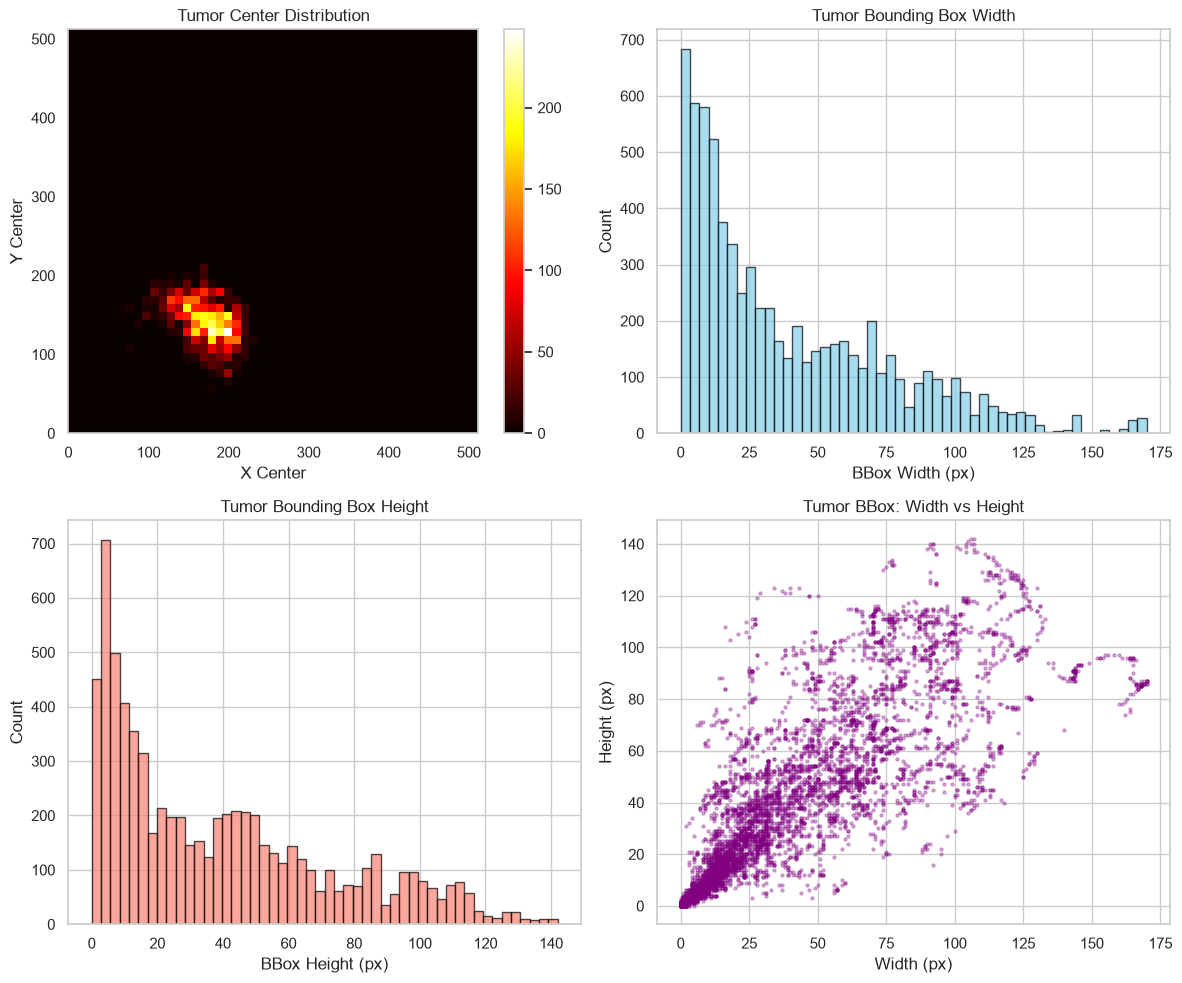

In [14]:
if tumor_bboxes:
    centers_x = [(b[0] + b[2]) / 2.0 for b in tumor_bboxes]
    centers_y = [(b[1] + b[3]) / 2.0 for b in tumor_bboxes]
    widths = [b[2] - b[0] for b in tumor_bboxes]
    heights = [b[3] - b[1] for b in tumor_bboxes]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].hist2d(centers_x, centers_y, bins=50, cmap='hot', range=[[0, 512], [0, 512]])
    axes[0, 0].set_xlabel('X Center'); axes[0, 0].set_ylabel('Y Center')
    axes[0, 0].set_title('Tumor Center Distribution')
    plt.colorbar(axes[0, 0].collections[0], ax=axes[0, 0])

    axes[0, 1].hist(widths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('BBox Width (px)'); axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Tumor Bounding Box Width')

    axes[1, 0].hist(heights, bins=50, color='salmon', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('BBox Height (px)'); axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Tumor Bounding Box Height')

    axes[1, 1].scatter(widths, heights, alpha=0.3, s=5, color='purple')
    axes[1, 1].set_xlabel('Width (px)'); axes[1, 1].set_ylabel('Height (px)')
    axes[1, 1].set_title('Tumor BBox: Width vs Height')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'tumor_bbox_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Split Analysis

In [15]:
log('\n## SPLIT ANALYSIS')

def load_volume_splits(splits_dir):
    result = {}
    for name in ['train', 'val', 'test']:
        fp = Path(splits_dir) / f'{name}_volumes.txt'
        if fp.exists():
            text = fp.read_text().strip()
            if ',' in text:
                result[name] = [int(x.strip()) for x in text.split(',') if x.strip()]
            else:
                result[name] = [int(x.strip()) for x in text.split() if x.strip()]
    return result

splits = load_volume_splits(SPLITS_DIR)
split_stats = {}
for name in ['train', 'val', 'test']:
    if name not in splits:
        log(f'  WARNING: {name} split file not found in {SPLITS_DIR}')
        continue
    vids = splits[name]
    n_slices = sum(len(vol_to_slices.get(v, [])) for v in vids)
    n_tumor_slices = 0
    for v in vids:
        for mp in (p for p in all_masks if f'mask-{v:03d}-' in p.name):
            m = load_mask(mp)
            if m.max() > 0:
                n_tumor_slices += 1
    split_stats[name] = {'volumes': len(vids), 'slices': n_slices, 'tumor_slices': n_tumor_slices}
    log(f'  {name.upper():5s}: {len(vids):3d} vols, {n_slices:6d} slices '
        f'({n_tumor_slices:5d} tumor, {100*n_tumor_slices/max(n_slices,1):.1f}%)')


## SPLIT ANALYSIS


  TRAIN: 104 vols,  40667 slices ( 4887 tumor, 12.0%)


  VAL  :  13 vols,  10685 slices ( 1035 tumor, 9.7%)


  TEST :  14 vols,   7286 slices ( 1192 tumor, 16.4%)


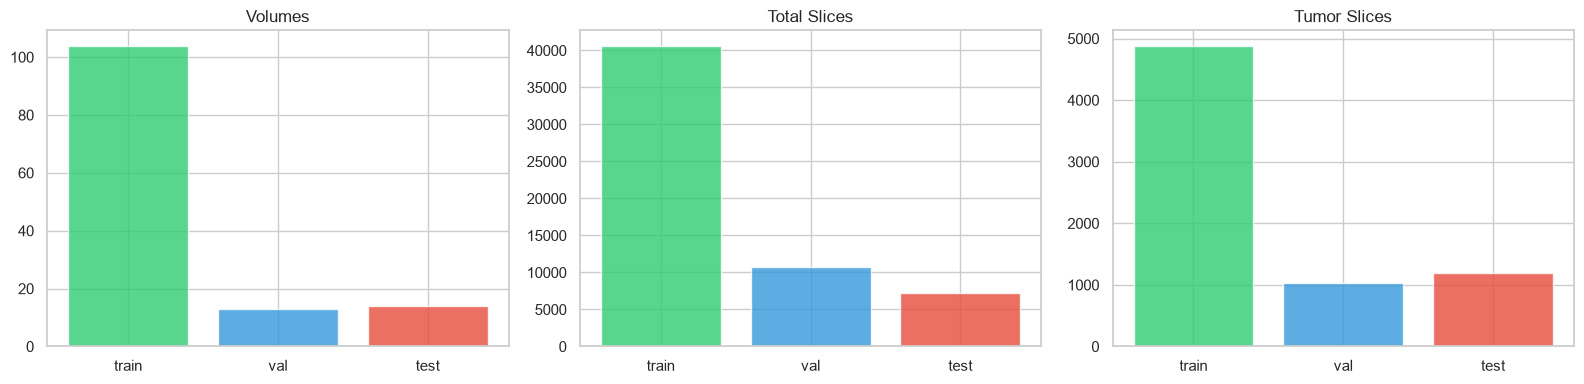

In [16]:
if split_stats:
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for i, (name, stats) in enumerate(split_stats.items()):
        axes[0].bar(i, stats['volumes'], color=colors[i], alpha=0.8)
        axes[1].bar(i, stats['slices'], color=colors[i], alpha=0.8)
        axes[2].bar(i, stats['tumor_slices'], color=colors[i], alpha=0.8)
    for ax, title in zip(axes, ['Volumes', 'Total Slices', 'Tumor Slices']):
        ax.set_xticks(range(len(split_stats)))
        ax.set_xticklabels(list(split_stats.keys()))
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'split_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


## Split Tumor Burden Comparison
  train: mean=0.100%  median=0.016%  range=[0.000, 1.191]
  val: mean=0.087%  median=0.003%  range=[0.000, 0.621]
  test: mean=0.307%  median=0.067%  range=[0.000, 2.119]


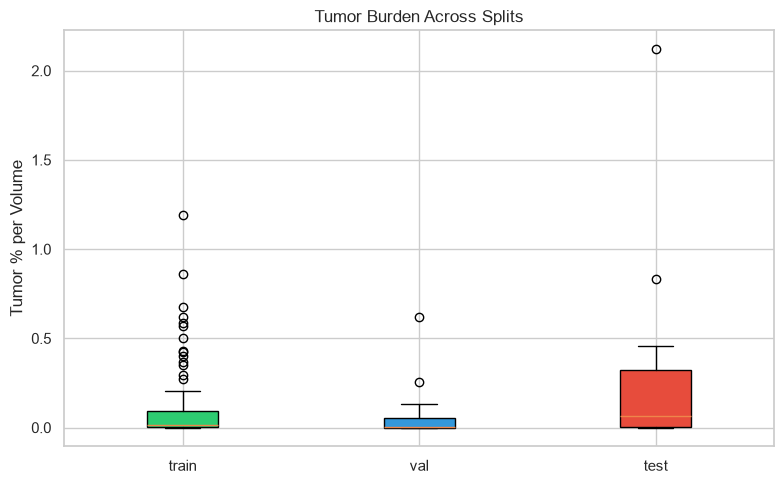

In [17]:
if split_stats and vol_tumor_pct:
    log('\n## Split Tumor Burden Comparison')
    all_tumor_pcts = []
    for name in ['train', 'val', 'test']:
        if name not in splits:
            continue
        pcts = [vol_tumor_pct[v] for v in splits[name] if v in vol_tumor_pct]
        all_tumor_pcts.append(pcts)
        log(f'  {name}: mean={np.mean(pcts):.3f}%  median={np.median(pcts):.3f}%  '
            f'range=[{min(pcts):.3f}, {max(pcts):.3f}]')

    if len(all_tumor_pcts) >= 2:
        fig, ax = plt.subplots(figsize=(8, 5))
        bp = ax.boxplot(all_tumor_pcts, patch_artist=True)
        ax.set_xticklabels(list(split_stats.keys()))
        for patch, color in zip(bp['boxes'], colors[:len(all_tumor_pcts)]):
            patch.set_facecolor(color)
        ax.set_ylabel('Tumor % per Volume'); ax.set_title('Tumor Burden Across Splits')
        ax.grid(True, axis='y')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'split_tumor_burden.png', dpi=150, bbox_inches='tight')
        plt.show()

---
## 7. Sample Visualization


## SAMPLE VISUALIZATIONS


  Displaying 8 sample slices


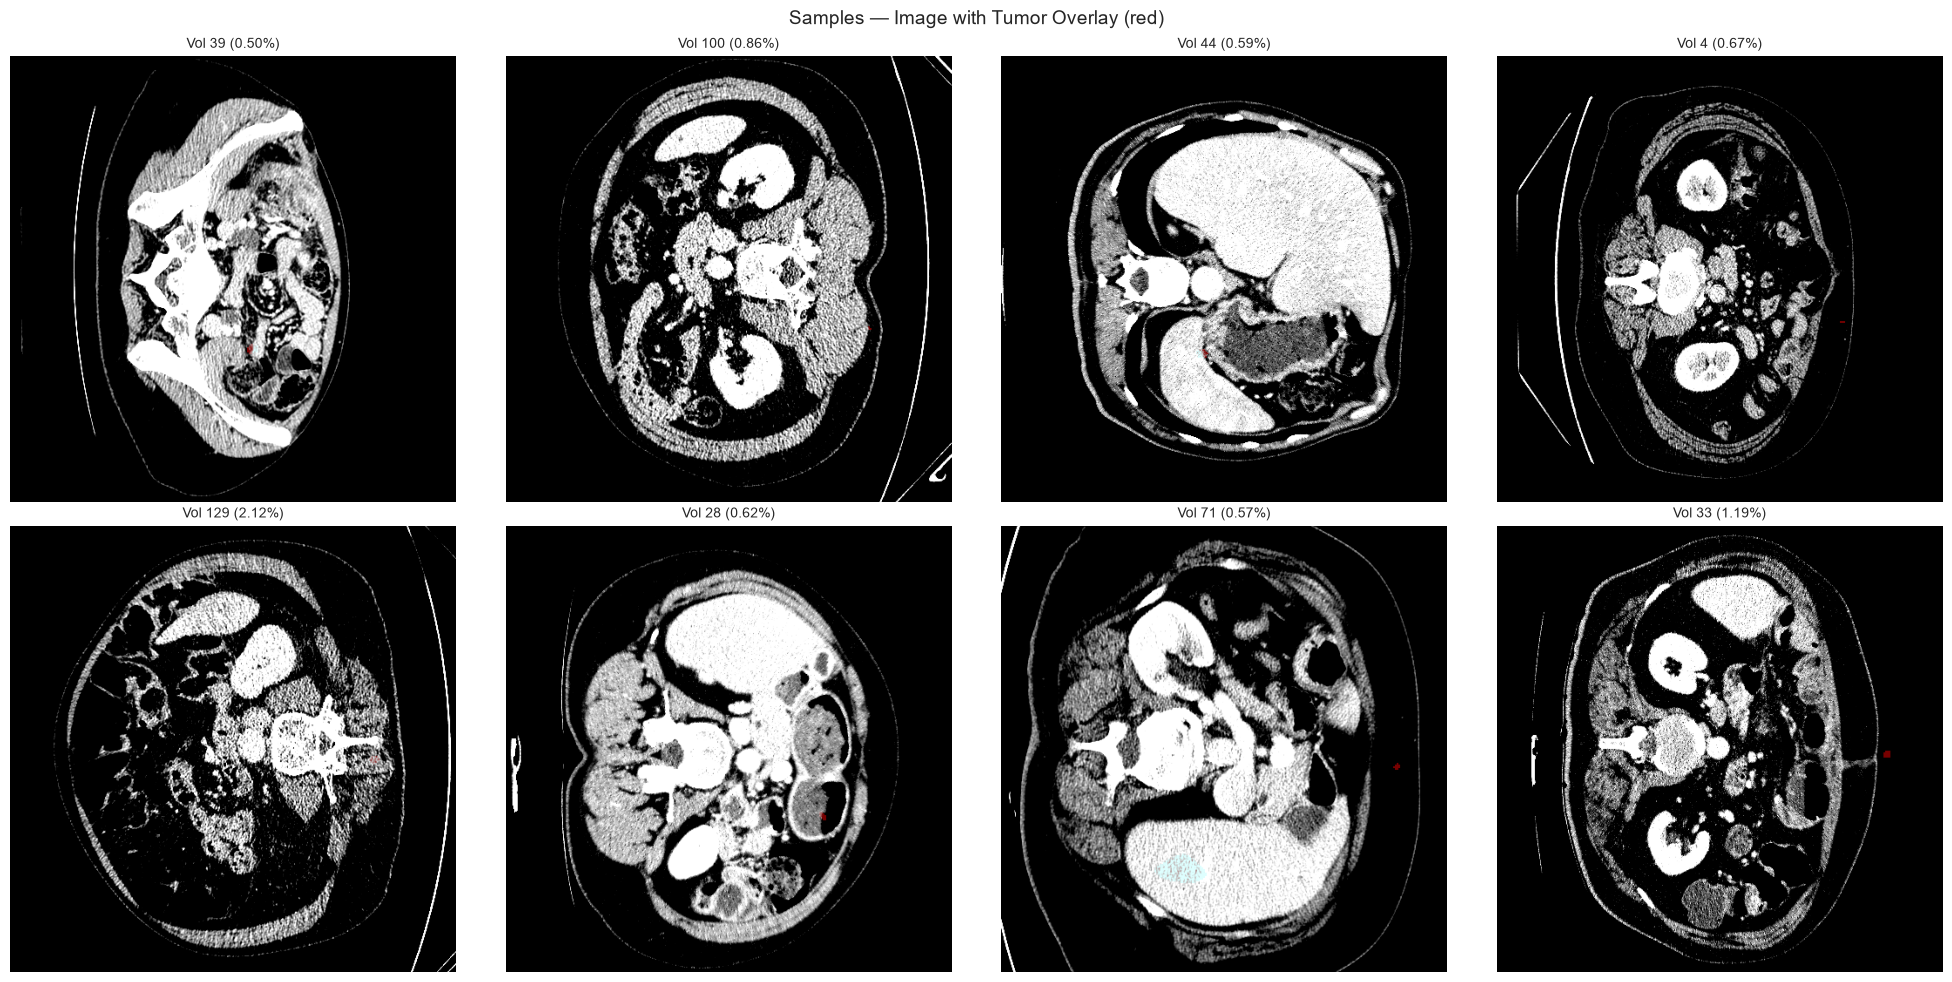

In [18]:
log('\n## SAMPLE VISUALIZATIONS')

tumor_vols = sorted(v for v, p in vol_tumor_pct.items() if p > 0.5)
rng.shuffle(tumor_vols)
samples = []
for sv in tumor_vols[:min(8, len(tumor_vols))]:
    vol_masks = sorted(
        p for p in all_masks if f'mask-{sv:03d}-' in p.name and np.array(Image.open(p)).max() > 0)
    if vol_masks:
        mp = vol_masks[0]
        ip = MASKS_DIR.parent / 'Liver Img Dataset' / mp.name.replace('mask-', 'Volume-')
        if ip.exists():
            samples.append((ip, mp, sv))

log(f'  Displaying {len(samples)} sample slices')

if samples:
    n_cols = 4; n_rows = math.ceil(len(samples) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.ravel() if n_rows * n_cols > 1 else [axes]
    for i, (ip, mp, vid) in enumerate(samples):
        img = np.array(Image.open(ip))
        mask = np.array(Image.open(mp))
        mask = match_mask_size(mask, img)
        overlay = np.stack([img]*3, axis=-1).astype(np.float32)
        overlay[..., 0] = np.where(mask > 0, overlay[..., 0]*0.4 + 200*0.6, overlay[..., 0])
        axes[i].imshow(overlay.astype(np.uint8).clip(0, 255))
        axes[i].set_title(f'Vol {vid} ({vol_tumor_pct.get(vid, 0):.2f}%)', fontsize=10)
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.suptitle('Samples — Image with Tumor Overlay (red)', fontsize=14)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'sample_overlays.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No tumor-positive samples found')

---
## 8. Preprocessing Pipeline


## PREPROCESSING PIPELINE


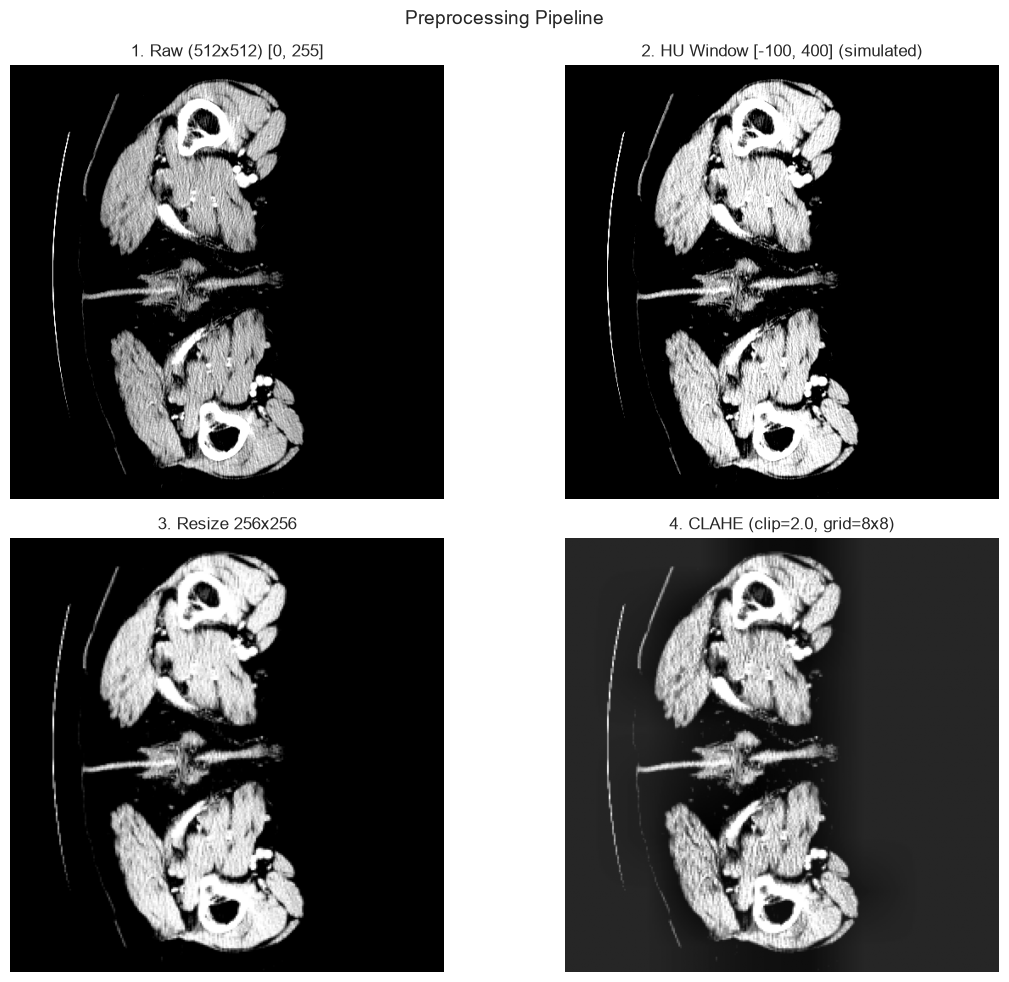

In [19]:
log('\n## PREPROCESSING PIPELINE')

raw_img = np.array(Image.open(all_images[0])).astype(np.float32)

# Simulated HU windowing (images are already windowed 8-bit PNG, this is for illustration)
HU_LOW, HU_HIGH = -100, 400
scale_low, scale_high = HU_LOW / 500.0, HU_HIGH / 500.0
img_hu = np.clip(raw_img / 255.0, scale_low, scale_high)
img_hu = (img_hu - scale_low) / (scale_high - scale_low)

img_resized = cv2.resize(img_hu, (256, 256), interpolation=cv2.INTER_LINEAR)

clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe_obj.apply((img_resized * 255).astype(np.uint8)) / 255.0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(raw_img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title(f'1. Raw (512x512) [{int(raw_img.min())}, {int(raw_img.max())}]')
axes[0, 1].imshow(img_hu, cmap='gray')
axes[0, 1].set_title(f'2. HU Window [{HU_LOW}, {HU_HIGH}] (simulated)')
axes[1, 0].imshow(img_resized, cmap='gray')
axes[1, 0].set_title('3. Resize 256x256')
axes[1, 1].imshow(img_clahe, cmap='gray')
axes[1, 1].set_title('4. CLAHE (clip=2.0, grid=8x8)')
for ax in axes.ravel():
    ax.axis('off')
plt.suptitle('Preprocessing Pipeline', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Augmentation Visualization


## DATA AUGMENTATION


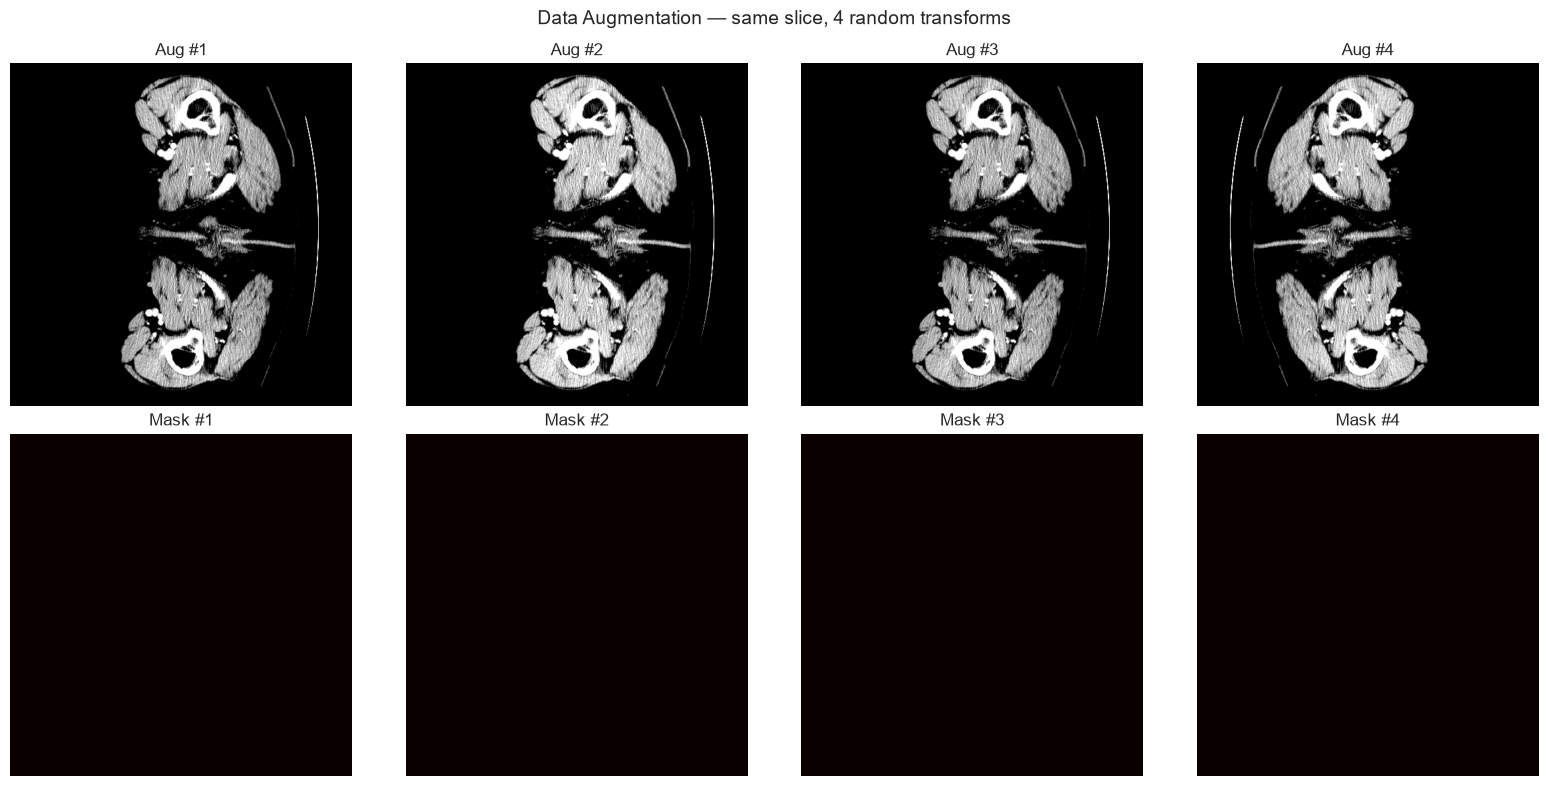

In [20]:
log('\n## DATA AUGMENTATION')

def apply_augmentation(img, mask):
    img = img.astype(np.float32)
    mask = mask.astype(np.float32)
    if np.random.rand() < 0.5:
        img = np.fliplr(img).copy()
        mask = np.fliplr(mask).copy()
    if np.random.rand() < 0.5:
        shift = np.random.uniform(-0.1, 0.1)
        img = np.clip(img + shift, 0, 1)
    return img, mask

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col in range(4):
    base_img = np.array(Image.open(all_images[0])) / 255.0
    base_mask = (np.array(Image.open(all_masks[0])) > 0).astype(np.float32)
    base_mask = match_mask_size(base_mask, base_img)
    aug_img, aug_mask = apply_augmentation(base_img.copy(), base_mask.copy())
    axes[0, col].imshow(aug_img, cmap='gray')
    axes[0, col].set_title(f'Aug #{col+1}')
    axes[1, col].imshow(aug_mask, cmap='hot', vmin=0, vmax=1)
    axes[1, col].set_title(f'Mask #{col+1}')
    axes[0, col].axis('off'); axes[1, col].axis('off')
plt.suptitle('Data Augmentation — same slice, 4 random transforms', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Correlation Analysis


## CORRELATION ANALYSIS


  Correlation matrix:
                         n_slices  mean_intensity    tumor_pixels       tumor_pct
        n_slices:         1.0000         -0.0533          0.2405         -0.0263
  mean_intensity:        -0.0533          1.0000          0.1130          0.1799
    tumor_pixels:         0.2405          0.1130          1.0000          0.8318
       tumor_pct:        -0.0263          0.1799          0.8318          1.0000


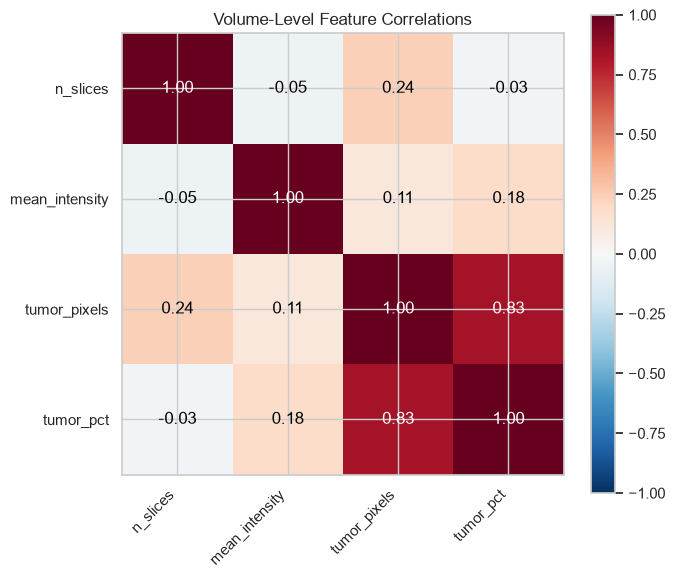

In [21]:
log('\n## CORRELATION ANALYSIS')

vol_stats = []
for vid in sorted(vol_to_slices.keys()):
    vol_imgs = [p for p in all_images if f'Volume-{vid:03d}-' in p.name]
    vol_ms   = [p for p in all_masks  if f'mask-{vid:03d}-' in p.name]
    intensities = []
    tumor_px_vol = 0
    for ip, mp in zip(vol_imgs, vol_ms):
        img = np.array(Image.open(ip))
        mask = np.array(Image.open(mp))
        mask = match_mask_size(mask, img)
        intensities.append(img.mean())
        tumor_px_vol += (mask > 0).sum()
    vol_stats.append({
        'volume': vid,
        'n_slices': len(vol_imgs),
        'mean_intensity': float(np.mean(intensities)),
        'tumor_pixels': tumor_px_vol,
        'tumor_pct': 100.0 * tumor_px_vol / (len(vol_imgs) * 512 * 512) if vol_imgs else 0
    })

# Manual correlation matrix
keys = ['n_slices', 'mean_intensity', 'tumor_pixels', 'tumor_pct']
data = {k: [vs[k] for vs in vol_stats] for k in keys}
n = len(vol_stats)
corr_matrix = np.eye(len(keys))
for i, k1 in enumerate(keys):
    for j, k2 in enumerate(keys):
        if i >= j:
            continue
        a, b = np.array(data[k1]), np.array(data[k2])
        a_s = (a - a.mean()) / (a.std() + 1e-10)
        b_s = (b - b.mean()) / (b.std() + 1e-10)
        corr = (a_s * b_s).mean()
        corr_matrix[i, j] = corr
        corr_matrix[j, i] = corr

log('  Correlation matrix:')
log(f'  {"":>16s} {"  ".join(f"{k:>14s}" for k in keys)}')
for i, k1 in enumerate(keys):
    row = '  '.join(f'{corr_matrix[i,j]:14.4f}' for j in range(len(keys)))
    log(f'  {k1:>14s}: {row}')

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(keys))); ax.set_yticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=45, ha='right')
ax.set_yticklabels(keys)
for i in range(len(keys)):
    for j in range(len(keys)):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black')
ax.set_title('Volume-Level Feature Correlations')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Data Quality Check

In [22]:
log('\n## DATA QUALITY')

corrupted = []
for p in all_images:
    try:
        Image.open(p).verify()
    except Exception:
        corrupted.append(str(p))
log(f'  Corrupted images: {len(corrupted)} / {len(all_images)}')

missing_masks = []
for img_path in all_images:
    mask_name = img_path.name.replace('Volume-', 'mask-')
    mp = MASKS_DIR / mask_name
    if not mp.exists():
        missing_masks.append(str(img_path))
log(f'  Images missing mask: {len(missing_masks)} / {len(all_images)}')

N_QC = min(2000, len(all_images))
idxs_qc = rng.choice(len(all_images), N_QC, replace=False)
empty_images = sum(1 for idx in idxs_qc if np.array(Image.open(all_images[idx])).max() == 0)
log(f'  Sampled {N_QC} slices: {empty_images} all-black, {N_QC-empty_images} non-black')

if not corrupted and not missing_masks:
    log('  Data quality — no issues found.')
else:
    log('  Data quality issues found.')


## DATA QUALITY


  Corrupted images: 0 / 58638


  Images missing mask: 0 / 58638


  Sampled 2000 slices: 0 all-black, 2000 non-black
  Data quality — no issues found.


---
## 12. Volume Slice Progression


## VOLUME SLICE PROGRESSION (Volume 4)
  Total slices: 841


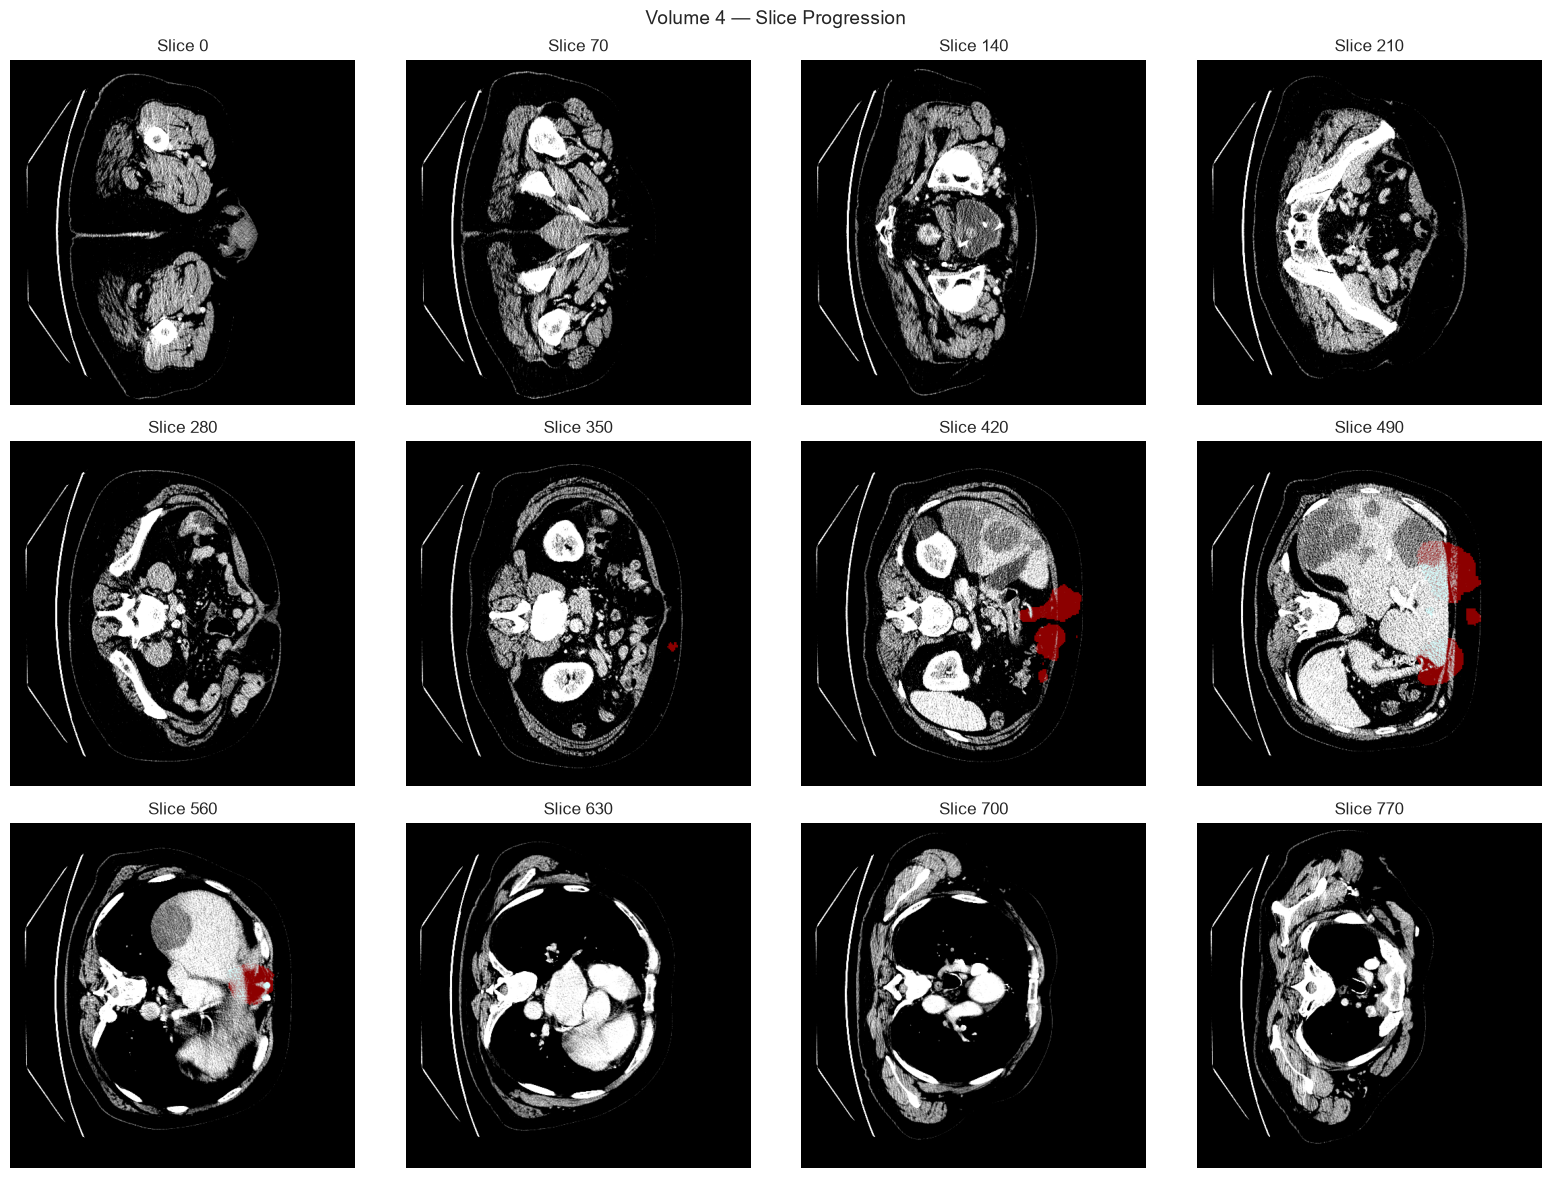

In [23]:
if vol_tumor_pct:
    demo_vol = sorted(v for v, p in vol_tumor_pct.items() if p > 0.5)[0]
else:
    demo_vol = volume_ids[0]
vol_imgs_demo = sorted([p for p in all_images if f'Volume-{demo_vol:03d}-' in p.name])
log(f'\n## VOLUME SLICE PROGRESSION (Volume {demo_vol})')
log(f'  Total slices: {len(vol_imgs_demo)}')

step = max(1, len(vol_imgs_demo) // 12)
selected = list(range(0, len(vol_imgs_demo), step))[:12]
n_cols = 4; n_rows = math.ceil(len(selected) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.ravel() if n_rows * n_cols > 1 else [axes]

for i, si in enumerate(selected):
    ip = vol_imgs_demo[si]
    mp = MASKS_DIR / ip.name.replace('Volume-', 'mask-')
    img = np.array(Image.open(ip))
    mask = np.array(Image.open(mp))
    mask = match_mask_size(mask, img)
    overlay = np.stack([img]*3, axis=-1).astype(np.float32)
    overlay[..., 0] = np.where(mask > 0, overlay[..., 0]*0.3 + 200*0.7, overlay[..., 0])
    axes[i].imshow(overlay.astype(np.uint8).clip(0, 255))
    axes[i].set_title(f'Slice {si}'); axes[i].axis('off')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle(f'Volume {demo_vol} — Slice Progression', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'volume_progression.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Summary Statistics

In [24]:
log('\n' + '=' * 70)
log('EDA COMPLETE — CONSOLIDATED SUMMARY')
log('=' * 70)

summary_blocks = []

header = f'''
DATABASE OVERVIEW
  Total volumes:        {n_volumes}
  Total slices:         {len(all_images):,}
  Image format:         PNG, 512x512, 8-bit grayscale
  Mask format:          PNG, 512x512, binary (0=bg, 1=liver+tumor)

CLASS BALANCE
  Tumor-positive slices: ~{tumor_slice_pct:.1f}% (est.)
  Pixel imbalance BG:FG: {pixel_imbalance:.0f}:1
  Volumes w/ zero tumor: {n_zero_tumor}/{n_volumes} ({100*n_zero_tumor/n_volumes:.0f}%)

SPLITS
'''
summary_blocks.append(header)

for name in ['train', 'val', 'test']:
    if name in split_stats:
        s = split_stats[name]
        pct = 100*s['tumor_slices']/max(s['slices'],1)
        summary_blocks.append(f'  {name.upper():5s}: {s["volumes"]} vols, {s["slices"]:,} slices ({pct:.1f}% tumor)\n')

tail = f'''
PREPROCESSING
  HU window:            [-100, 400]
  Resize:               256x256
  CLAHE:                clip=2.0, grid=8x8 (optional)
  Augmentation:         horiz flip (p=0.5), intensity shift (+-0.1, p=0.5)

TUMOR MORPHOLOGY
  Mean tumor size:      {tumor_sizes.mean():.0f} px per slice
  Median tumor size:    {np.median(tumor_sizes):.0f} px per slice
  Tumor size range:     [{tumor_sizes.min()}, {tumor_sizes.max():,}] px
'''
summary_blocks.append(tail)

log(''.join(summary_blocks))

print('\n' + '=' * 60)
print('EDA COMPLETE')
print(f'All data written to: {EDA_FILE}')
print(f'All plots saved to: {PLOTS_DIR}/')
print('=' * 60)


EDA COMPLETE — CONSOLIDATED SUMMARY

DATABASE OVERVIEW
  Total volumes:        131
  Total slices:         58,638
  Image format:         PNG, 512x512, 8-bit grayscale
  Mask format:          PNG, 512x512, binary (0=bg, 1=liver+tumor)

CLASS BALANCE
  Tumor-positive slices: ~12.6% (est.)
  Pixel imbalance BG:FG: 822:1
  Volumes w/ zero tumor: 13/131 (10%)

SPLITS
  TRAIN: 104 vols, 40,667 slices (12.0% tumor)
  VAL  : 13 vols, 10,685 slices (9.7% tumor)
  TEST : 14 vols, 7,286 slices (16.4% tumor)

PREPROCESSING
  HU window:            [-100, 400]
  Resize:               256x256
  CLAHE:                clip=2.0, grid=8x8 (optional)
  Augmentation:         horiz flip (p=0.5), intensity shift (+-0.1, p=0.5)

TUMOR MORPHOLOGY
  Mean tumor size:      631 px per slice
  Median tumor size:    234 px per slice
  Tumor size range:     [1, 3,764] px


EDA COMPLETE
All data written to: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\eda_data.txt
All plots saved to: D:\DATA SCIENCE AND ANA